# 1. Your first SCHISM model

**What this shows:** the smallest complete SCHISM setup built with rompy-schism: the
tide off Perth on an unstructured mesh, from the input files to a model run and maps
of the water level and currents.

**Prerequisites:** none. This is the start of the [tutorial](../README.md). If you are
new to rompy, [What rompy does](../../../docs/why-rompy.md) gives the big picture first.

**You will learn:**

- how rompy and rompy-schism split the work between *what* the model is and *when and
  where* it runs
- how a mesh, a tidal open boundary and model settings come together in a
  `SCHISMConfig`
- how `ModelRun` writes a SCHISM workspace: `param.nml`, `bctides.in` and the mesh files
- how to run SCHISM with Docker, and how to check that the run succeeded

**Data used:** `hgrid.gr3`, a mesh of the coast off Perth, Western Australia, and
`tides/`, TPXO9 tidal constituents, in the [`data/`](../data) folder of this
repository.

## How the pieces fit together

[SCHISM](https://schism-dev.github.io/schism/master/) computes water levels,
currents and, in 3D, temperature and salinity on an unstructured mesh of triangles,
so the resolution can follow the coast. It reads a set of input files. rompy-schism
describes them with three objects, and [rompy](https://rom-py.github.io/rompy/) adds
the run period and writes the files:

```text
ModelRun                    rompy: the run period, the output directory, generates files
└── config: SCHISMConfig    rompy-schism: the SCHISM input files
    ├── grid: SCHISMGrid    hgrid.gr3 (mesh and depths), vgrid.in, friction and other
    │                       property files (*.gr3)
    ├── data: SCHISMData    bctides.in (open boundaries) and boundary files,
    │                       sflux/ (atmosphere), wave boundaries, hotstart.nc
    └── nml: NML            param.nml (model settings), and the namelists of the
                            modules (waves, sediment, ...)
```

Each object checks its own settings, and together they write the workspace.

## Setup

The example data ships with this repository. Outputs go to a local `_output` folder
that is safe to delete.

In [1]:
import shutil
import subprocess
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.tri as mtri
import numpy as np
import xarray as xr
from rompy.logging import config as logging_config

logging_config.update(level="ERROR")  # rompy logs every step, show errors only

DATA_DIR = Path("../data")
OUT_DIR = Path("_output") / "01_first_model"
shutil.rmtree(OUT_DIR, ignore_errors=True)

## 1. Run period

`TimeRange` comes from rompy and defines when the model runs: two days from
1 January 2023. SCHISM takes its start date and run length (`rnday`) from it.

In [2]:
from rompy.core.time import TimeRange

period = TimeRange(start="2023-01-01T00:00", end="2023-01-03T00:00", interval="1h")

## 2. The mesh

`SCHISMGrid` points to the mesh, `hgrid.gr3`: the nodes with their depths, the
triangles, and which parts of the outline are open sea and which are land. This
mesh has triangles of about 400 m at the coast growing to 2.5 km offshore, and its
west, north and south sides are open. [Tutorial 2](02_mesh_and_vertical_grid.ipynb)
looks at it in detail.

SCHISM also needs bottom friction everywhere. Here it is a constant drag
coefficient; rompy-schism warns that a map of friction is better, which
[Tutorial 5](05_model_settings.ipynb) comes back to.

[Text(0.5, 1.0, '6790 nodes, 12958 triangles'), None]

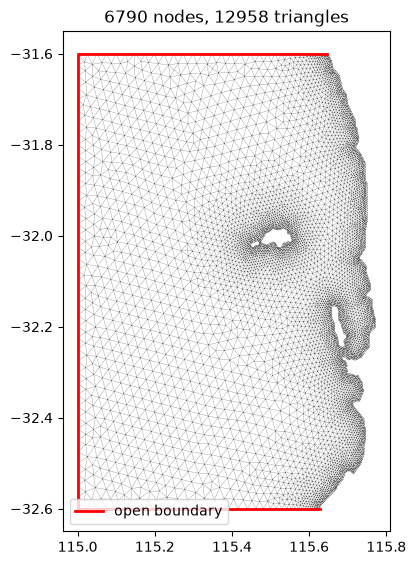

In [3]:
from rompy.core.data import DataBlob
from rompy_schism.grid import SCHISMGrid

grid = SCHISMGrid(hgrid=DataBlob(source=DATA_DIR / "hgrid.gr3"), drag=0.0025)

hgrid = grid.pylibs_hgrid
triangulation = mtri.Triangulation(hgrid.x, hgrid.y, hgrid.elnode[:, :3])
fig, ax = plt.subplots(figsize=(6, 6.5))
ax.triplot(triangulation, color="0.4", linewidth=0.2)
for nodes in hgrid.iobn:
    ax.plot(hgrid.x[nodes], hgrid.y[nodes], "r", linewidth=2, label="open boundary")
ax.legend(loc="lower left")
ax.set(title=f"{hgrid.np} nodes, {hgrid.ne} triangles", aspect=1 / np.cos(np.radians(32)))

## 3. The tide at the open boundary

The tide enters through the open boundary. `TidalDataset` points to a database of
tidal constituents (here the global TPXO9 model around Perth) and chooses which to
use. `SCHISMDataBoundaryConditions` sets what each open boundary does: elevation
and currents from the tidal constituents. [Tutorial 3](03_tides_and_open_boundaries.ipynb)
explains the options.

In [4]:
from rompy_schism.boundary_core import TidalDataset
from rompy_schism.data import (
    BoundarySetupWithSource,
    SCHISMData,
    SCHISMDataBoundaryConditions,
)

tides = TidalDataset(
    tidal_database=DATA_DIR / "tides",
    tidal_model="TPXO9-perth",
    constituents=["M2", "S2", "N2", "K2", "K1", "O1", "P1", "Q1"],
    nodal_corrections=True,
)
boundary_conditions = SCHISMDataBoundaryConditions(
    tidal_data=tides,
    default_boundary=BoundarySetupWithSource(elev_type=3, vel_type=3),
)
data = SCHISMData(boundary_conditions=boundary_conditions)

## 4. Model settings

`param.nml` holds SCHISM's settings in three groups, `CORE`, `OPT` and `SCHOUT`, and
`NML(param=Param(...))` sets them. Only what differs from the defaults is given:

- **`ibc=1`, `ibtp=0`:** a barotropic model, driven by the tide alone. rompy-schism
  defaults to a baroclinic model, which needs temperature and salinity.
- **`dt=120`:** a 2-minute time step. SCHISM is semi-implicit, so the time step is
  not limited by the mesh size as in explicit models.
- **`nspool=30`, `ihfskip=720`:** write the output every 30 steps (1 hour), in one
  file per 720 steps (1 day).
- **Output:** water level (`iof_hydro(1)`) and depth-averaged velocity
  (`iof_hydro(16)`). The 3D velocity, on by default, is not needed in a 2D model.

In [5]:
from rompy_schism.namelists import NML, Param

nml = NML(
    param=Param(
        core={"ibc": 1, "ibtp": 0, "dt": 120.0, "nspool": 30, "ihfskip": 720},
        schout={"iof_hydro__1": 1, "iof_hydro__16": 1, "iof_hydro__26": 0},
    )
)

## 5. Assemble the model and generate the workspace

`SCHISMConfig` gathers the pieces, and `ModelRun` combines it with the run period and
an output directory. Calling it writes the workspace into `output_dir/run_id`.

In [6]:
from rompy.model import ModelRun
from rompy_schism.config import SCHISMConfig

config = SCHISMConfig(grid=grid, data=data, nml=nml)
modelrun = ModelRun(
    run_id="first_model", period=period, output_dir=OUT_DIR, config=config
)
workspace = Path(modelrun())
sorted(p.name for p in workspace.iterdir())

['README',
 'albedo.gr3',
 'bctides.in',
 'datasets',
 'diffmax.gr3',
 'diffmin.gr3',
 'drag.gr3',
 'hgrid.gr3',
 'hgrid.ll',
 'hgrid_WWM.gr3',
 'outputs',
 'param.nml',
 'sflux',
 'tvd.prop',
 'vgrid.in',
 'watertype.gr3',
 'windrot_geo2proj.gr3',
 'wwmbnd.gr3']

Besides the mesh, the workspace has the property files SCHISM reads (`drag.gr3` and
others, one value per node), `vgrid.in` (a single layer: this is a 2D model) and
`outputs/`, where SCHISM writes. The run length and start date in `param.nml` come
from the run period:

In [7]:
param_nml = (workspace / "param.nml").read_text()
settings = ("ibc", "dt", "rnday", "nspool", "ihfskip", "start_year", "start_month")
print("\n".join(line for line in param_nml.splitlines() if line.startswith(settings)))

ibc = 1
rnday = 2.0
dt = 120.0
nspool = 30
ihfskip = 720
start_year = 2023
start_month = 1
ibcc_mean = 0
dtb_max = 30.0
dtb_min = 10.0
nspool_sta = 10


`bctides.in` describes the open boundary. After the tidal constituents comes one
line per open boundary with its number of nodes and four flags: elevation `3` and
velocity `3` are tidal, temperature and salinity `0` are not used. The tidal amplitude
and phase at each boundary node follow.

In [8]:
bctides = (workspace / "bctides.in").read_text().splitlines()
start = next(i for i, line in enumerate(bctides) if "!nope" in line)
print("\n".join(bctides[start : start + 4]))

1 !nope
115 3 3 0 0 !open boundary 1
z0
0.000000 0.0


## 6. Run SCHISM

SCHISM is not a Python package. The easiest way to run it is the public Docker image
`ghcr.io/rom-py/schism`, used here through rompy's `DockerConfig` backend. SCHISM
always runs under MPI: `schism 2` asks for 2 *scribes*, processes that only write
output, out of the 6 started (`cpu=6`). If Docker is not installed, this step is
skipped.

SCHISM returns success even when it stops with an error, so rompy cannot tell. The
run finished only if SCHISM's log, `outputs/mirror.out`, ends with "Run completed
successfully"; errors are in `outputs/fatal.error`.

In [9]:
from rompy.backends import DockerConfig

SCHISM_IMAGE = "ghcr.io/rom-py/schism:5.13.0"


def docker_available() -> bool:
    """Return True if the Docker daemon can be reached."""
    try:
        return subprocess.run(["docker", "info"], capture_output=True).returncode == 0
    except FileNotFoundError:
        return False


def run_completed(workspace: Path) -> bool:
    """Check SCHISM's log: SCHISM exits with success even when it stops on an error."""
    mirror = workspace / "outputs" / "mirror.out"
    if mirror.exists() and "Run completed successfully" in mirror.read_text():
        return True
    fatal = workspace / "outputs" / "fatal.error"
    print(fatal.read_text() if fatal.exists() else "SCHISM did not finish")
    return False


if docker_available():
    backend = DockerConfig(
        image=SCHISM_IMAGE, executable="schism 2", mpiexec="mpirun", cpu=6
    )
    modelrun.run(backend, workspace_dir=workspace)
    print("SCHISM finished" if run_completed(workspace) else "SCHISM failed")
else:
    print("Docker is not available, skipping the model run")

SCHISM finished


## 7. Results

SCHISM writes 2D fields to `outputs/out2d_N.nc`, one file per day here (`ihfskip`).
They include the mesh, so a triangulation for plotting comes from the output itself.

In [10]:
out2d_files = sorted((workspace / "outputs").glob("out2d_*.nc"))
if out2d_files:
    out2d = xr.open_mfdataset(
        out2d_files, data_vars="minimal", coords="minimal", compat="override"
    )
    x = out2d.SCHISM_hgrid_node_x.values
    y = out2d.SCHISM_hgrid_node_y.values
    triangulation = mtri.Triangulation(
        x, y, out2d.SCHISM_hgrid_face_nodes.values[:, :3] - 1
    )
    print(out2d.elevation)

<xarray.DataArray 'elevation' (time: 48, nSCHISM_hgrid_node: 6790)> Size: 1MB
dask.array<concatenate, shape=(48, 6790), dtype=float32, chunksize=(1, 6790), chunktype=numpy.ndarray>
Coordinates:
  * time                 (time) datetime64[ns] 384B 2023-01-01T01:00:00 ... 2...
    SCHISM_hgrid_node_x  (nSCHISM_hgrid_node) float64 54kB dask.array<chunksize=(6790,), meta=np.ndarray>
    SCHISM_hgrid_node_y  (nSCHISM_hgrid_node) float64 54kB dask.array<chunksize=(6790,), meta=np.ndarray>
Dimensions without coordinates: nSCHISM_hgrid_node
Attributes:
    i23d:          1
    location:      node
    grid_mapping:  crs
    mesh:          SCHISM_hgrid


Maps of the second day, once the tide is fully ramped up. The tide here is small and
mostly diurnal, rising and falling once a day. Its range varies by only about a
centimetre, growing towards the coast and in Cockburn Sound, behind Garden Island. Tidal currents are weak offshore, a few centimetres per second, and strongest
around the islands and headlands. The fast currents where the open boundary meets the
coast, in the north-east and south-east corners, come from forcing the boundary there
and are not realistic; they stay confined to the corners.

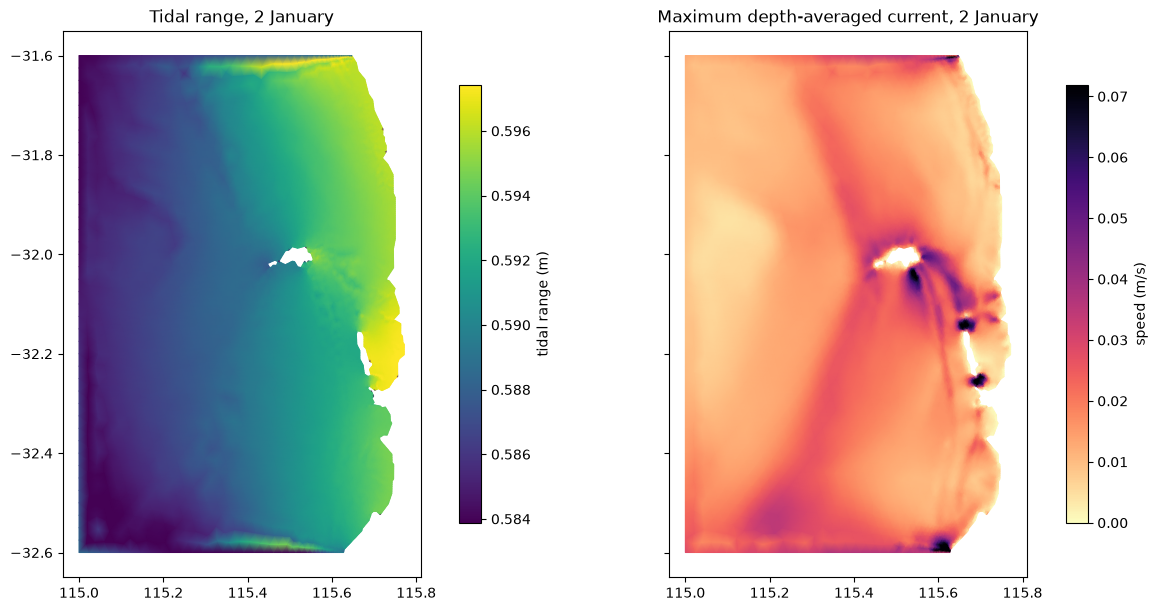

In [11]:
if out2d_files:
    day2 = out2d.sel(time=slice("2023-01-02", None))
    tidal_range = (day2.elevation.max("time") - day2.elevation.min("time")).values
    speed = np.hypot(day2.depthAverageVelX, day2.depthAverageVelY).max("time").values
    fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True, layout="constrained")
    maps = [
        (tidal_range, "viridis", "tidal range (m)", "Tidal range"),
        (speed, "magma_r", "speed (m/s)", "Maximum depth-averaged current"),
    ]
    for ax, (values, cmap, label, title) in zip(axes, maps):
        vmin, vmax = np.percentile(values, [1, 99])  # ignore a few drying nodes
        tpc = ax.tripcolor(
            triangulation, values, cmap=cmap, shading="gouraud", vmin=vmin, vmax=vmax
        )
        fig.colorbar(tpc, ax=ax, label=label, shrink=0.8)
        ax.set(title=f"{title}, 2 January", aspect=1 / np.cos(np.radians(32)))

A time series at a point offshore. SCHISM starts from rest and ramps the tide up over
the first day (`dramp=1`), so the first day is not yet the full tide.

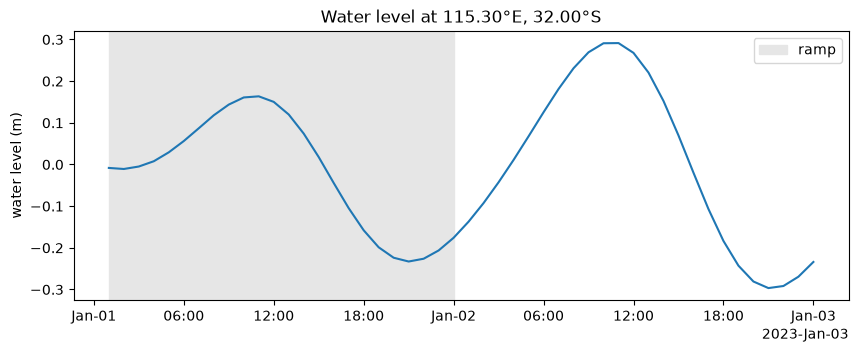

In [12]:
if out2d_files:
    offshore = np.argmin((x - 115.3) ** 2 + (y + 32.0) ** 2)
    series = out2d.elevation[:, offshore]
    fig, ax = plt.subplots(figsize=(10, 3.5))
    series.plot(ax=ax)
    ax.axvspan(
        series.time[0].values, np.datetime64("2023-01-02"), color="0.9", label="ramp"
    )
    ax.set(
        title=f"Water level at {x[offshore]:.2f}°E, {-y[offshore]:.2f}°S",
        ylabel="water level (m)",
        xlabel="",
    )
    ax.legend()

## Next steps

You now have the whole workflow. The next tutorials look at each part in turn:

- [2. The mesh and the vertical grid](02_mesh_and_vertical_grid.ipynb)
- [3. Tides and open boundaries](03_tides_and_open_boundaries.ipynb)
- [4. Atmospheric forcing](04_atmospheric_forcing.ipynb)
- [5. Choosing model settings](05_model_settings.ipynb)
- [6. A tide and wind hindcast](06_tide_and_wind_hindcast.ipynb)
- [7. Configuration as YAML and the rompy CLI](07_yaml_and_cli.ipynb)